# Fraud Detection Assignment
Implementasi end-to-end deteksi fraud menggunakan MLFlow dan Optuna.

In [ ]:
# Re-installing libraries quietly for the T4 runtime session
!pip install -q mlflow optuna catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

In [ ]:
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/MLUTS/train_transaction.csv'
df = pd.read_csv(path)
print(f'Shape dataset: {df.shape}')
display(df.head())

Mounted at /content/drive
Shape dataset: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis (EDA)
Mari kita lihat distribusi target `isFraud` dan korelasi antar fitur.

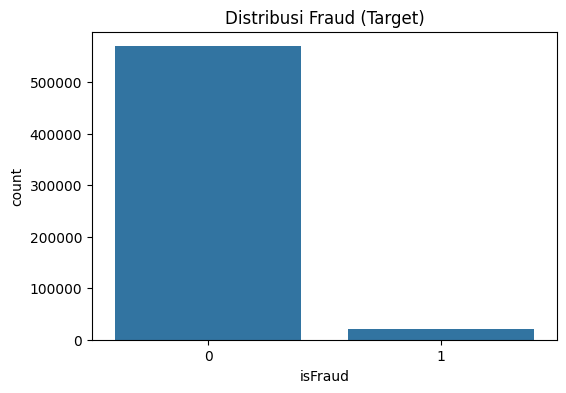

Persentase Fraud:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title('Distribusi Fraud (Target)')
plt.show()

print("Persentase Fraud:")
print(df['isFraud'].value_counts(normalize=True) * 100)

### Analisis Distribusi Target
Grafik di atas menunjukkan bahwa dataset sangat tidak seimbang (*imbalanced*). Mayoritas transaksi (~96.5%) adalah normal (0), sedangkan transaksi fraud (1) hanya sekitar 3.5%. Hal ini sangat penting karena model ML cenderung mengabaikan kelas minoritas jika tidak ditangani dengan benar.

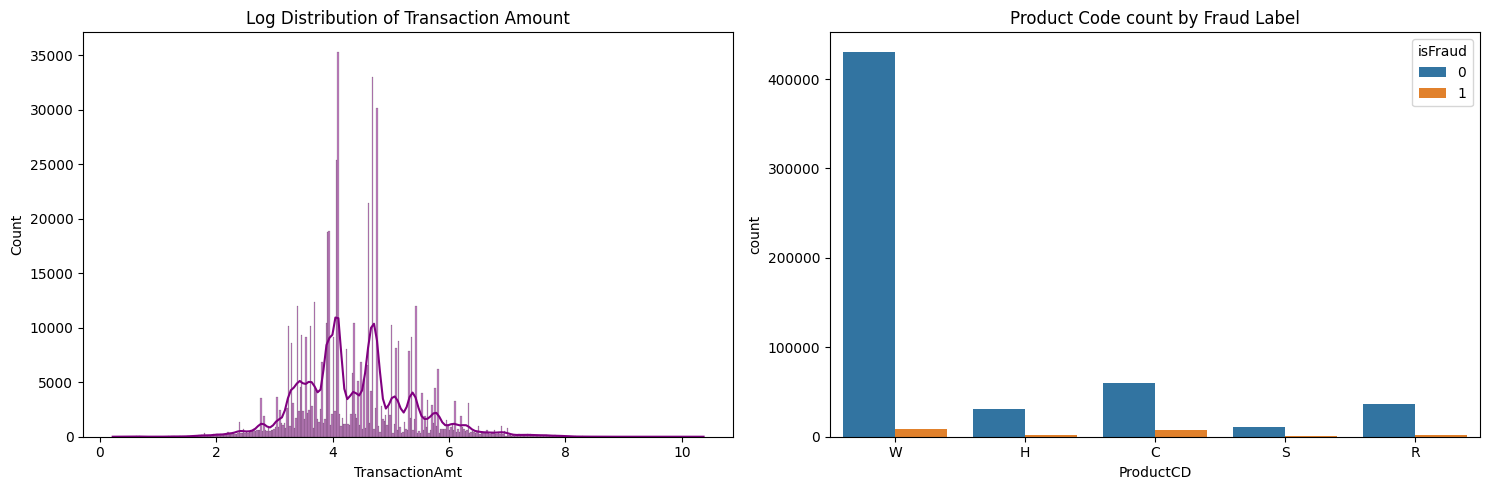

In [ ]:
plt.figure(figsize=(15, 5))

# Grafik 1: Distribusi Log TransactionAmt
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df['TransactionAmt']), kde=True, color='purple')
plt.title('Log Distribution of Transaction Amount')

# Grafik 2: ProductCD Count vs isFraud
plt.subplot(1, 2, 2)
sns.countplot(x='ProductCD', hue='isFraud', data=df)
plt.title('Product Code count by Fraud Label')

plt.tight_layout()
plt.show()

### Analisis Nilai Transaksi dan Kode Produk
1. **Log Distribution of Transaction Amount**: Kita menggunakan skala logaritmik karena nilai transaksi biasanya memiliki rentang yang sangat lebar (*skewed*). Grafik ini membantu kita melihat pola umum besaran transaksi.
2. **Product Code count by Fraud Label**: Grafik ini menunjukkan frekuensi penggunaan kode produk tertentu. Kita bisa melihat apakah ada kode produk (seperti 'C' atau 'W') yang memiliki kecenderungan fraud lebih tinggi dibanding yang lain.

## Data Preprocessing
Langkah ini mencakup penanganan missing values dan encoding variabel kategorikal.

In [ ]:
# Identifikasi kolom dengan banyak missing values
null_cols = [col for col in df.columns if df[col].isnull().sum() / df.shape[0] > 0.5]
df.drop(columns=null_cols, inplace=True)

# Isi missing values sisa (sederhana: median untuk numerik, mode untuk kategorikal)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

## Data Splitting
Sebelum melakukan training, kita memisahkan data menjadi **Training Set** (untuk melatih model) dan **Test Set** (untuk menguji performa model pada data yang belum pernah dilihat).

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan Fitur dan Target
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# One-hot encoding untuk data kategorikal
X = pd.get_dummies(X, drop_first=True)

# Splitting data (80% Train, 20% Test) dengan stratify agar proporsi fraud tetap seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 472432
Jumlah data testing: 118108


In [ ]:
# Preprocessing: Drop columns with > 50% missing values
null_cols = [col for col in df.columns if df[col].isnull().sum() / df.shape[0] > 0.5]
df.drop(columns=null_cols, inplace=True)

# Impute remaining missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Data cleaning complete. 'df' is ready for splitting and training.")

Data cleaning complete. 'df' is ready for splitting and training.


## Model Training with Optuna & MLFlow
Kita akan menggunakan CatBoost karena handal dalam menangani data tabular dengan banyak fitur kategorikal.

### Apa itu Hyperparameter Tuning?
Setiap algoritma (seperti CatBoost) memiliki 'pengaturan' internal yang disebut **Hyperparameters** (misalnya `learning_rate` atau `depth`). Tuning adalah proses mencari kombinasi pengaturan terbaik agar model memiliki akurasi atau AUC tertinggi.

Fungsinya:
- Menghindari model yang terlalu sederhana (*underfitting*) atau terlalu kompleks (*overfitting*).
- Memaksimalkan kemampuan prediksi model pada dataset spesifik ini.
- Kita menggunakan **Optuna**, framework otomatis yang mencoba berbagai kombinasi secara cerdas untuk menemukan hasil terbaik.

In [ ]:
import mlflow
import optuna
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Fungsi objektif untuk Optuna
def objective(trial):
    param = {
        "iterations": 100,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "eval_metric": "AUC",
        "random_seed": 42,
        "logging_level": "Silent"
    }

    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds)
    return auc

# Menjalankan Tuning
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(f"Best AUC: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-06-22 08:36:19,974] A new study created in memory with name: no-name-35d84e8e-6039-4405-9d47-d2f7a2831b0f
[I 2026-06-22 08:37:11,874] Trial 0 finished with value: 0.8866893333404803 and parameters: {'learning_rate': 0.04786682439903583, 'depth': 8, 'l2_leaf_reg': 7.450638776628268}. Best is trial 0 with value: 0.8866893333404803.
[I 2026-06-22 08:37:55,480] Trial 1 finished with value: 0.8882520197722715 and parameters: {'learning_rate': 0.06774043473153353, 'depth': 7, 'l2_leaf_reg': 3.016950496562826}. Best is trial 1 with value: 0.8882520197722715.
[I 2026-06-22 08:38:28,286] Trial 2 finished with value: 0.8834454932817022 and parameters: {'learning_rate': 0.16455040936159, 'depth': 4, 'l2_leaf_reg': 6.7561321253514315}. Best is trial 1 with value: 0.8882520197722715.
[I 2026-06-22 08:38:57,855] Trial 3 finished with value: 0.8900798313500966 and parameters: {'learning_rate': 0.22694593787309, 'depth': 4, 'l2_leaf_reg': 3.5125142217192433}. Best is trial 3 with value: 0.8900

Best AUC: 0.920873278684444
Best Params: {'learning_rate': 0.2878522012633904, 'depth': 8, 'l2_leaf_reg': 2.6936014404630364}


In [ ]:
# Menjalankan ulang tuning dengan trials lebih banyak
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(f"Best AUC after 20 trials: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-06-22 08:49:50,484] A new study created in memory with name: no-name-b1eb2c80-ddb6-4f5d-83ad-718a47c169b8
[I 2026-06-22 08:50:30,812] Trial 0 finished with value: 0.8955264383996324 and parameters: {'learning_rate': 0.10757030859623418, 'depth': 7, 'l2_leaf_reg': 8.60474683136189}. Best is trial 0 with value: 0.8955264383996324.
[I 2026-06-22 08:51:16,329] Trial 1 finished with value: 0.9140366972330994 and parameters: {'learning_rate': 0.1869856906931843, 'depth': 8, 'l2_leaf_reg': 1.6905904687830902}. Best is trial 1 with value: 0.9140366972330994.
[I 2026-06-22 08:51:47,659] Trial 2 finished with value: 0.8730707199055405 and parameters: {'learning_rate': 0.08248090507238048, 'depth': 4, 'l2_leaf_reg': 4.979239408052061}. Best is trial 1 with value: 0.9140366972330994.
[I 2026-06-22 08:52:17,340] Trial 3 finished with value: 0.8936589990620596 and parameters: {'learning_rate': 0.2795852571259866, 'depth': 4, 'l2_leaf_reg': 5.522122347323223}. Best is trial 1 with value: 0.91

Best AUC after 20 trials: 0.9155723159116007
Best Params: {'learning_rate': 0.2098983305988777, 'depth': 8, 'l2_leaf_reg': 2.6870570512330993}


## Final Evaluation & MLflow Tracking
Melatih model final dengan parameter terbaik dan mencatatnya ke MLflow.

2026/06/22 09:03:23 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/22 09:03:23 INFO mlflow.store.db.utils: Updating database tables
2026/06/22 09:03:25 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_Experiment' does not exist. Creating a new experiment.


Final AUC on Test Set: 0.9492825421376647

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.93      0.55      0.69      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.77      0.84    118108
weighted avg       0.98      0.98      0.98    118108



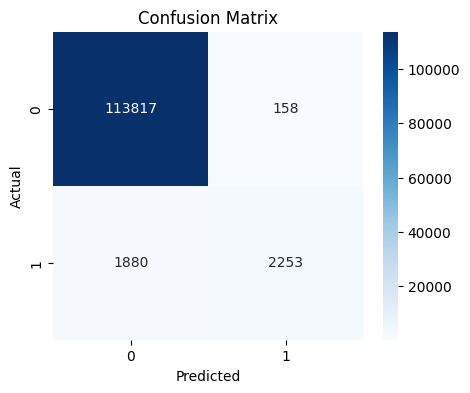

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Memulai experiment MLflow
mlflow.set_experiment("Fraud_Detection_Experiment")

with mlflow.start_run(run_name="Best_CatBoost_Model"):
    # Mengambil parameter terbaik dari Optuna
    best_params = study.best_params
    # Menambahkan iterasi untuk model final agar lebih optimal
    best_params['iterations'] = 500

    model = CatBoostClassifier(**best_params, eval_metric='AUC', logging_level='Silent')
    model.fit(X_train, y_train)

    # Prediksi
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Hitung Metrik
    final_auc = roc_auc_score(y_test, y_pred_proba)

    # Log parameters dan metrics ke MLflow
    mlflow.log_params(best_params)
    mlflow.log_metric("auc", final_auc)

    print(f"Final AUC on Test Set: {final_auc}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()